# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [3]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [4]:
penguins = sns.load_dataset('penguins')

In [ ]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [5]:
# 2) Verificar valores missing
print("Valores missing por coluna:")
print(penguins.isnull().sum())

# 3) Remover linhas com valores faltantes
penguins = penguins.dropna()

print("\nApós remover missing:")
print(penguins.isnull().sum())

# 4) Remover colunas categóricas
penguins_kmeans = penguins.drop(columns=['species', 'island', 'sex'])

# 5) Visualizar dataset final
print("\nDataset pronto para K-Means:")
print(penguins_kmeans.head())

# 6) Verificar dimensões finais
print("\nShape final:")
print(penguins_kmeans.shape)

Valores missing por coluna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Após remover missing:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Dataset pronto para K-Means:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0

Shape final:
(333, 4)


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

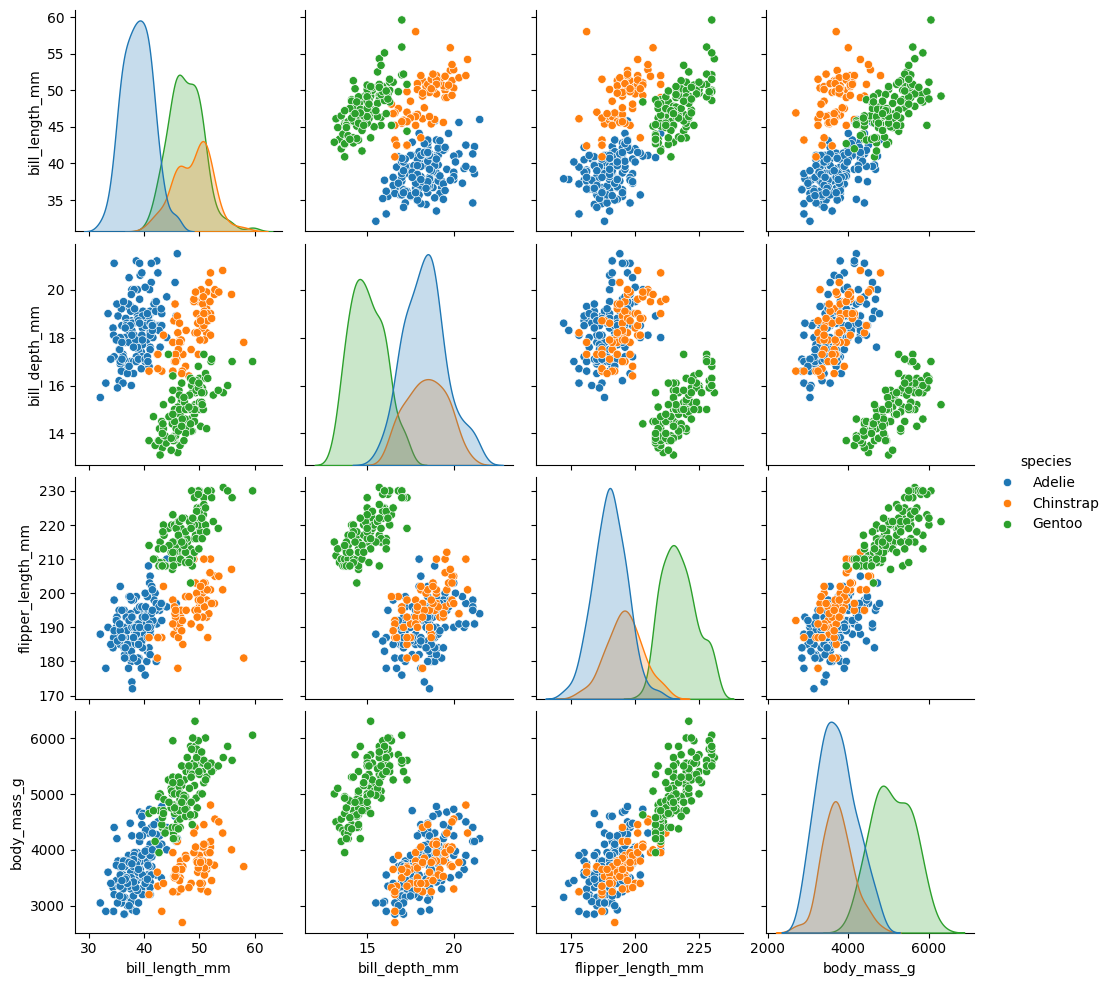

In [7]:
import matplotlib.pyplot as plt

# 1° Pairplot com cores por espécie
sns.pairplot(
    penguins,
    hue='species'
)

plt.show()

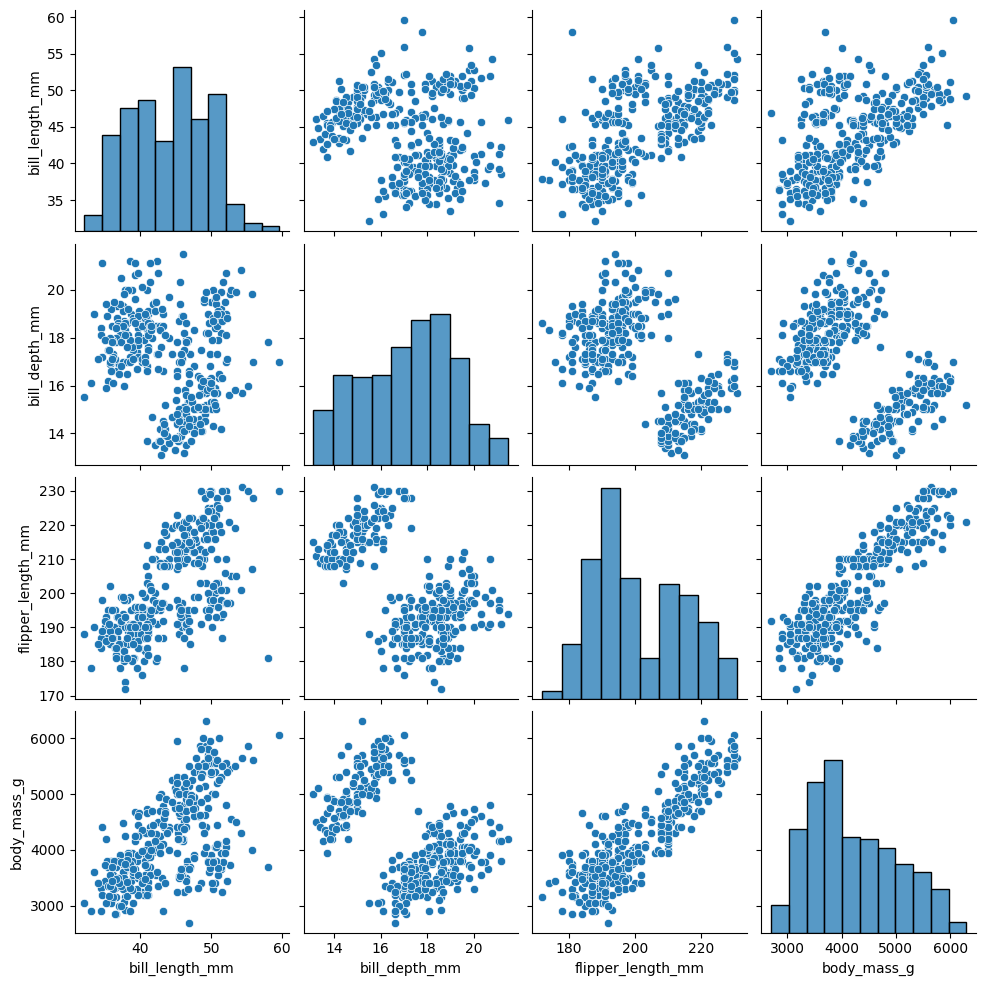

In [6]:


# 2° Pairplot dos dados numéricos
sns.pairplot(penguins_kmeans)

plt.show()

Com base na comparação entre os dois pairplots, é possível identificar possíveis agrupamentos nos dados. No primeiro gráfico, em que os pontos estão coloridos pelas espécies reais (Adelie, Chinstrap e Gentoo), observa-se que a espécie Gentoo se destaca claramente das demais, principalmente nas variáveis comprimento da nadadeira (flipper length) e massa corporal (body mass), formando um grupo bem separado. Já as espécies Adelie e Chinstrap apresentam certa sobreposição em algumas combinações de variáveis, como comprimento e profundidade do bico, mas ainda demonstram tendências de separação.

No segundo pairplot, sem a coloração por espécie, a identificação dos grupos se torna menos evidente, porém ainda é possível perceber regiões com maior concentração de pontos, indicando a presença de possíveis agrupamentos naturais. Dessa forma, é possível sugerir a existência de dois a três agrupamentos potenciais, sendo que o grupo correspondente à espécie Gentoo é o mais claramente isolado, enquanto os outros dois apresentam maior proximidade e sobreposição entre si.

- Com base na comparação entre os dois pairplots, é possível identificar possíveis agrupamentos nos dados. No gráfico com coloração por espécie, observa-se que a espécie Gentoo se destaca claramente, principalmente nas variáveis relacionadas ao comprimento da nadadeira e massa corporal, formando um grupo bem separado. Já as espécies Adelie e Chinstrap apresentam certa sobreposição, mas ainda indicam tendências de separação.


---


- No pairplot sem coloração, os agrupamentos ficam menos evidentes, mas ainda é possível perceber áreas com maior concentração de pontos. Assim, é possível sugerir a existência de dois a três agrupamentos potenciais, sendo o grupo Gentoo o mais isolado.

# 3 - Realize a padronização dos dados e visualize os dados.

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       -0.593407       0.451613          -0.695652    -0.244898
1       -0.549451       0.032258          -0.478261    -0.204082
2       -0.461538       0.225806          -0.086957    -0.653061
3       -0.857143       0.645161          -0.173913    -0.489796
4       -0.571429       1.064516          -0.304348    -0.326531


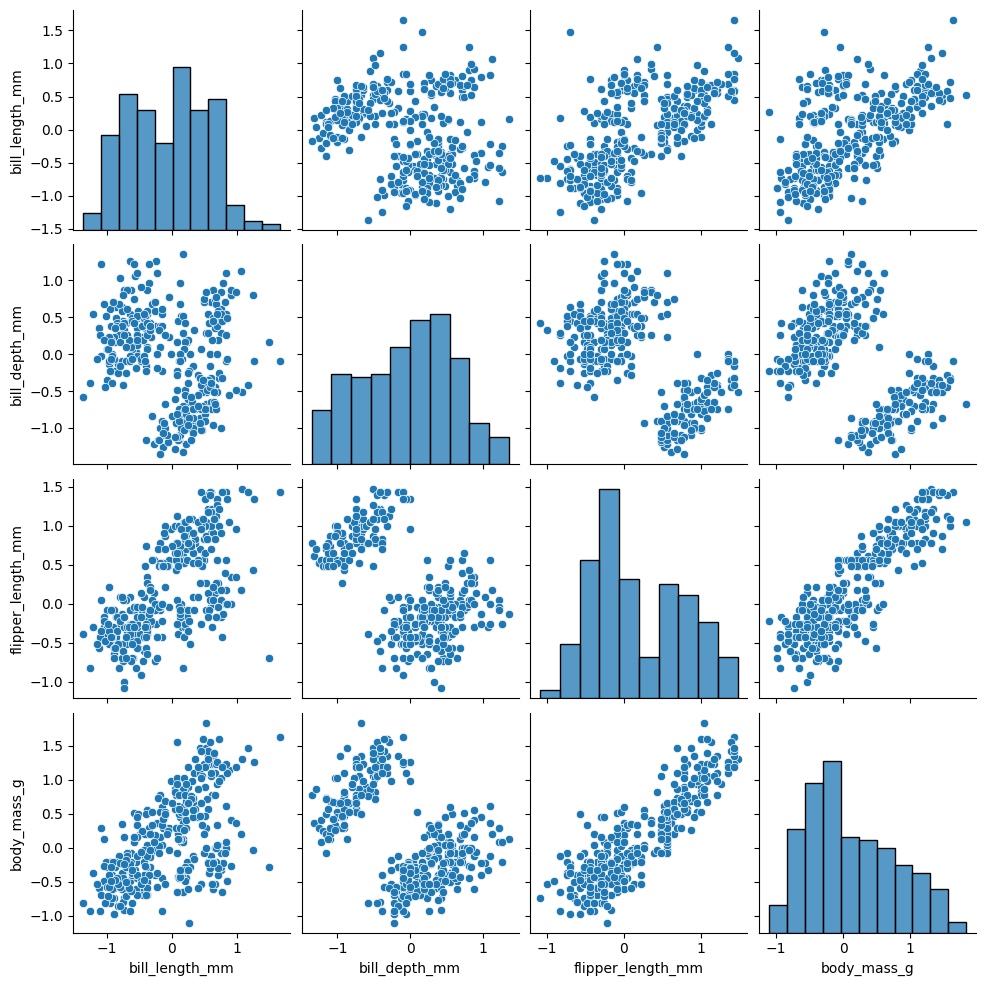

In [20]:
from sklearn.preprocessing import RobustScaler


# Criar o scaler
scaler = RobustScaler()

# Padronizar os dados
penguins_scaled = scaler.fit_transform(penguins_kmeans)

# Transformar em DataFrame
penguins_scaled = pd.DataFrame(
    penguins_scaled,
    columns=penguins_kmeans.columns
)

# Visualizar os primeiros dados
print(penguins_scaled.head())

# Visualizar os dados com pairplot
sns.pairplot(penguins_scaled)

plt.show()

# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [21]:
# Criar modelo K-Means com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Ajustar o modelo aos dados padronizados
kmeans.fit(penguins_scaled)

# Criar coluna com os clusters
penguins_scaled['cluster'] = kmeans.labels_

# Visualizar os primeiros dados com clusters
print(penguins_scaled.head())

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  cluster
0       -0.593407       0.451613          -0.695652    -0.244898        0
1       -0.549451       0.032258          -0.478261    -0.204082        0
2       -0.461538       0.225806          -0.086957    -0.653061        0
3       -0.857143       0.645161          -0.173913    -0.489796        0
4       -0.571429       1.064516          -0.304348    -0.326531        0


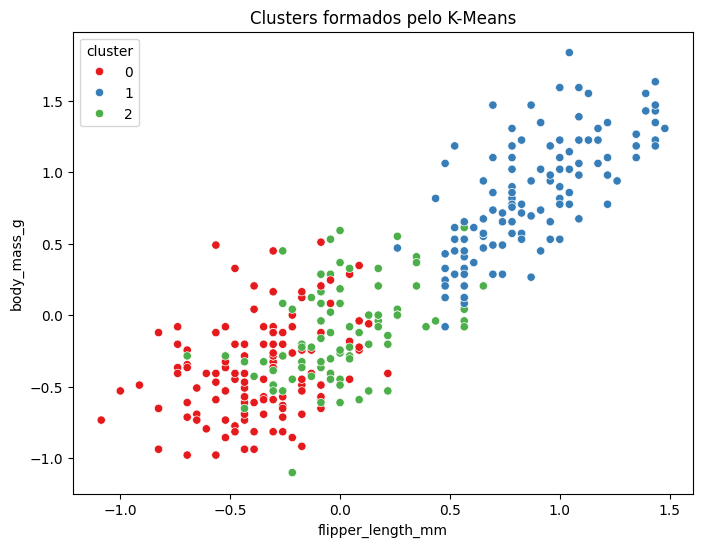

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_scaled,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='cluster',
    palette='Set1'
)

plt.title('Clusters formados pelo K-Means')
plt.show()

# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

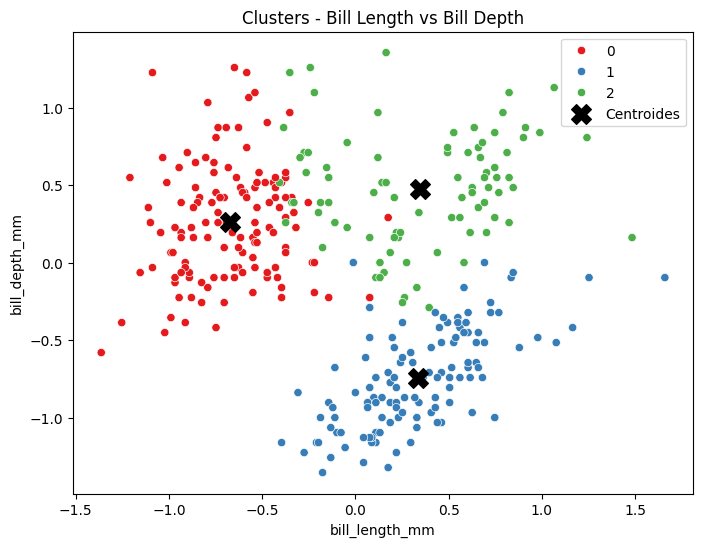

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_scaled,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='cluster',
    palette='Set1'
)

# Centróides
plt.scatter(
    centroids_df['bill_length_mm'],
    centroids_df['bill_depth_mm'],
    s=200,
    c='black',
    marker='X',
    label='Centroides'
)

plt.title('Clusters - Bill Length vs Bill Depth')
plt.legend()

plt.show()


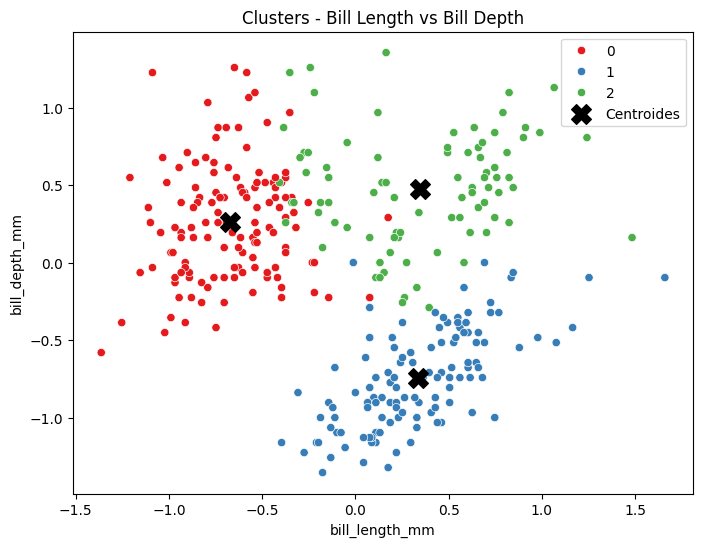

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_scaled,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='cluster',
    palette='Set1'
)

# Centróides
plt.scatter(
    centroids_df['bill_length_mm'],
    centroids_df['bill_depth_mm'],
    s=200,
    c='black',
    marker='X',
    label='Centroides'
)

plt.title('Clusters - Bill Length vs Bill Depth')
plt.legend()

plt.show()

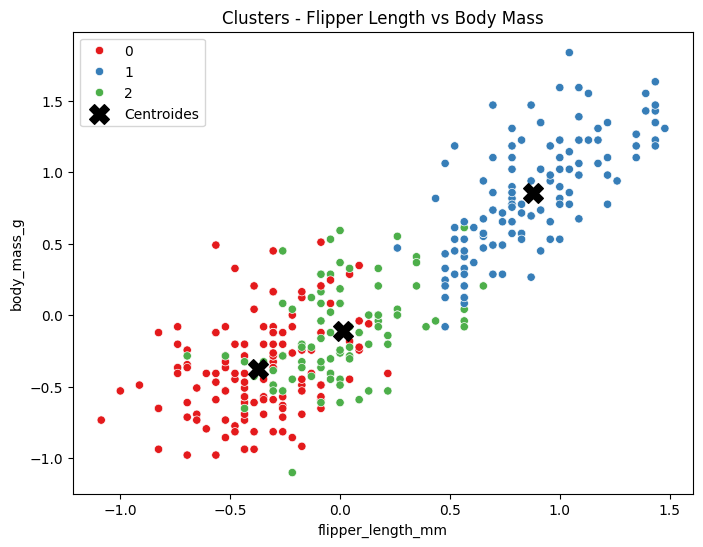

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_scaled,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='cluster',
    palette='Set1'
)

# Centróides
plt.scatter(
    centroids_df['flipper_length_mm'],
    centroids_df['body_mass_g'],
    s=200,
    c='black',
    marker='X',
    label='Centroides'
)

plt.title('Clusters - Flipper Length vs Body Mass')
plt.legend()

plt.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

**1. Saúde:**
Algoritmos de clusterização podem ser utilizados para agrupar pacientes com características clínicas semelhantes, como sintomas ou resultados de exames. Isso ajuda médicos a identificar padrões de doenças e possíveis subgrupos de pacientes. Também pode auxiliar na personalização de tratamentos e no diagnóstico precoce de determinadas condições.

**2. Vendas:**
Na área de vendas, a clusterização é usada para segmentar clientes com base em comportamentos de compra, preferências e frequência de consumo. Isso permite que empresas criem campanhas de marketing mais direcionadas para cada grupo. Como resultado, aumenta-se a eficiência das vendas e melhora-se o relacionamento com os clientes.

**3. Agricultura:**
Na agricultura, algoritmos de clusterização podem ser aplicados para agrupar áreas de cultivo com características semelhantes de solo, clima e produtividade. Isso auxilia agricultores na tomada de decisões sobre irrigação, fertilização e escolha de culturas. Dessa forma, é possível otimizar o uso de recursos e aumentar a produtividade das lavouras.